# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [1]:
STUDENT_NAME = "Trần Minh Khôi"  # TODO: Họ và tên
STUDENT_ID = "2550117"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Trần Minh Khôi (2550117)


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: C:\Users\Admin\Desktop\MLIOT\mliot-pyml-2026-hw\week02\numpy-pandas-eda-hw\data\automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [3]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [4]:
# TODO N1
shifted_logits = logits - np.max(logits, axis=1, keepdims=True)
exp_logits = np.exp(shifted_logits)
class_probabilities = exp_logits/np.sum(exp_logits, axis=1, keepdims=True)
predicted_classes = np.argmax(class_probabilities, axis=1)
confidence_scores = np.max(class_probabilities, axis=1)

In [5]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [6]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [7]:
# TODO N2
train_feature_mean = np.mean(X_train, axis=0, keepdims=True)
train_feature_std = np.std(X_train, axis=0, keepdims=True)
X_train_scaled = (X_train -train_feature_mean)/train_feature_std
X_val_scaled = (X_val -train_feature_mean)/train_feature_std

In [8]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [9]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [10]:
# TODO N3
correct_mask = predicted_classes == true_labels
high_confidence_mask = confidence_scores >= confidence_threshold
review_mask = ~correct_mask | ~high_confidence_mask
review_indices = review_indices = np.where(review_mask)[0]

## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [11]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [12]:
# TODO N4
normalized_batch = image_batch_uint8.astype(np.float32) / 255.0
augmented_batch = np.flip(normalized_batch, axis=2).copy()
augmented_batch[0, 0, 0, 0] = 1.0

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

1. Mỗi dòng đại diện cho một mẫu xe (sample) trong bộ dữ liệu 1985 Auto Imports.
2. Ký hiệu missing value trong CSV là dấu `?`.
3. `symboling` là mức đánh giá rủi ro bảo hiểm của xe, giá trị nguyên trong khoảng -3 đến 3 (càng cao càng rủi ro).


## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [13]:
# TODO D1
raw_df = pd.read_csv(DATA_PATH)
raw_shape = raw_df.shape
raw_missing_marker_count = (raw_df == '?').sum().sum()

## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [14]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [15]:
# TODO D2
df_clean = raw_df.replace('?', np.nan)
for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column])
missing_by_column = df_clean.isna().sum()

### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

- Không nên fill tất cả numeric columns bằng cùng một giá trị (vd. cùng một con số 0 hoặc cùng median chung) vì mỗi cột có thang đo và phân phối hoàn toàn khác nhau, nên một giá trị fill chung sẽ làm méo thống kê của hầu hết các cột thay vì chỉ cột cần fill. 

- Với `price`, ở bài EDA này nên **drop** 4 dòng thiếu thay vì fill: `price` là biến mục tiêu chính của toàn bộ phân tích (outlier, correlation, group-by đều xoay quanh nó), nên nếu fill bằng mean/median sẽ tạo ra giá trị giả định và làm lệch các kết luận về phân phối giá cũng như tương quan với engine_size — trong khi drop chỉ mất 4/205 dòng (~2%), không đáng kể. 

- Cột `normalized_losses` thiếu tới 41/205 dòng (~20%), nhiều hơn hẳn các cột còn lại; nếu drop toàn bộ những dòng này sẽ mất một lượng dữ liệu lớn và có thể mất luôn một số hãng xe ít phổ biến trong dataset, nên cách hợp lý hơn là loại `normalized_losses` ra khỏi các cột phân tích cốt lõi (đúng như `AUTO_FEATURES` đã làm) thay vì drop theo nó, hoặc nếu cần dùng thì nên fill có điều kiện (vd. theo median của từng `body_style`/`make`) thay vì drop thẳng.

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [16]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [17]:
# TODO D3
analysis_df = df_clean.dropna(subset=AUTO_FEATURES).reset_index(drop=True)
X_auto = analysis_df[AUTO_FEATURES].to_numpy(dtype=np.float64)
auto_feature_mean = np.mean(X_auto, axis=0, keepdims=True)
auto_feature_std = np.std(X_auto, axis=0, keepdims=True)
X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [18]:
# TODO D4
price_index = AUTO_FEATURES.index("price")
price_z = X_auto_scaled[:, price_index]
price_outlier_mask = np.abs(price_z) > 2
price_outliers = (
    analysis_df.loc[price_outlier_mask, ["make", "body_style", "price"]]
    .assign(price_z=price_z[price_outlier_mask])
    .sort_values("price_z", ascending=False)
)


## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [19]:
# TODO D5
engine_price_corr = np.corrcoef(analysis_df["engine_size"], analysis_df["price"])[0, 1]
price_by_body_style = analysis_df.groupby("body_style")["price"].mean().sort_index()

# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

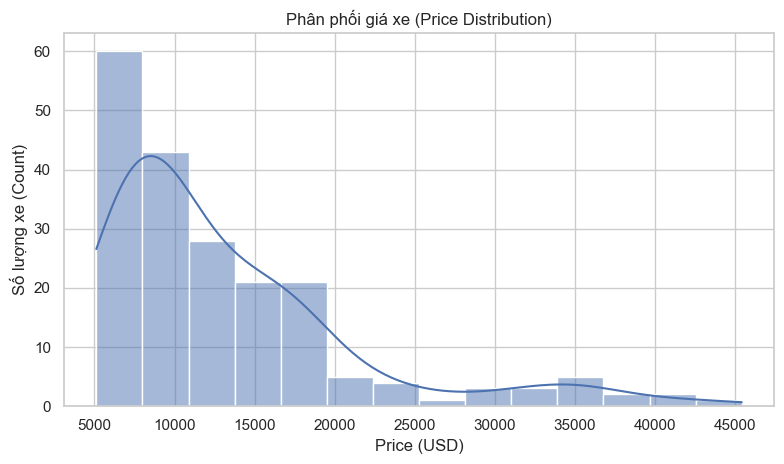

In [20]:
# TODO M2.1: histogram/KDE của price
fig, ax = plt.subplots()
sns.histplot(analysis_df["price"], kde=True, ax=ax)
ax.set_title("Phân phối giá xe (Price Distribution)")
ax.set_xlabel("Price (USD)")
ax.set_ylabel("Số lượng xe (Count)")
plt.tight_layout()
plt.show()

**Nhận xét:** Phân phối `price` lệch phải rõ rệt (skewness ≈ 1.79): phần lớn xe tập trung ở khoảng 5,000–15,000 USD, median (10,345 USD) thấp hơn hẳn mean (13,243 USD), và một số ít xe hạng sang kéo đuôi phân phối dài về phía giá cao (lên tới 45,400 USD).

## M2.2 Dataset có cân bằng theo body style không?

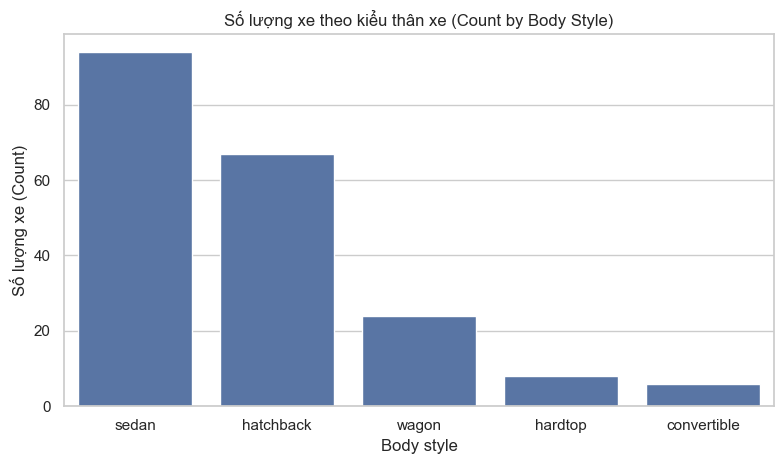

In [21]:
# TODO M2.2: countplot của body_style
fig, ax = plt.subplots()
sns.countplot(
    data=analysis_df, x="body_style",
    order=analysis_df["body_style"].value_counts().index, ax=ax,
)
ax.set_title("Số lượng xe theo kiểu thân xe (Count by Body Style)")
ax.set_xlabel("Body style")
ax.set_ylabel("Số lượng xe (Count)")
plt.tight_layout()
plt.show()

**Nhận xét:** Dataset không cân bằng theo `body_style`: sedan (94 xe) và hatchback (67 xe) chiếm gần 81% tổng số mẫu, trong khi hardtop (8 xe) và convertible (6 xe) rất hiếm — điều này cần lưu ý vì các kết luận về 2 nhóm thiểu số này (vd. trong boxplot D5/M2.3) sẽ kém tin cậy do cỡ mẫu quá nhỏ.

## M2.3 Price khác nhau theo body style ra sao?

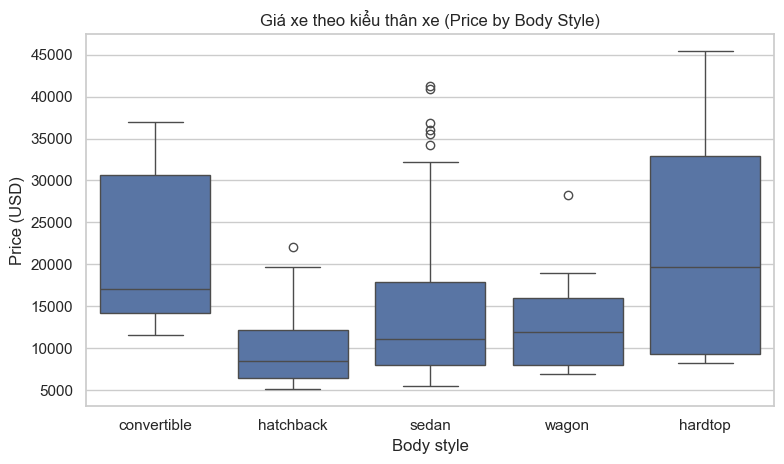

In [22]:
# TODO M2.3: boxplot price theo body_style
fig, ax = plt.subplots()
sns.boxplot(data=analysis_df, x="body_style", y="price", ax=ax)
ax.set_title("Giá xe theo kiểu thân xe (Price by Body Style)")
ax.set_xlabel("Body style")
ax.set_ylabel("Price (USD)")
plt.tight_layout()
plt.show()

**Nhận xét:** Convertible và hardtop có median price cao nhất và cũng có khoảng IQR rộng nhất (phù hợp với bảng `price_by_body_style` ở D5, trung bình khoảng 22,000 USD), trong khi hatchback có giá thấp nhất và tập trung dày đặc quanh median; sedan tuy đông mẫu nhất nhưng vẫn có vài outlier giá rất cao kéo dài lên trên (khớp với danh sách `price_outliers` ở D4, phần lớn là sedan hạng sang).

## M2.4 Engine size liên quan thế nào tới price?

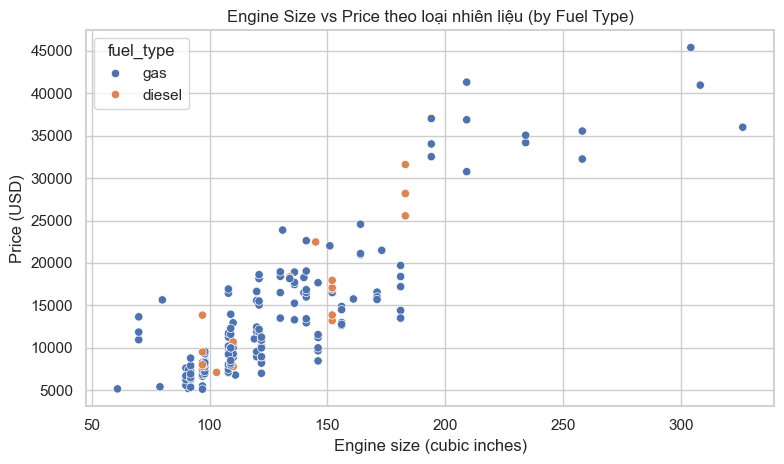

In [23]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
fig, ax = plt.subplots()
sns.scatterplot(data=analysis_df, x="engine_size", y="price", hue="fuel_type", ax=ax)
ax.set_title("Engine Size vs Price theo loại nhiên liệu (by Fuel Type)")
ax.set_xlabel("Engine size (cubic inches)")
ax.set_ylabel("Price (USD)")
plt.tight_layout()
plt.show()

**Nhận xét:** `engine_size` và `price` có quan hệ đồng biến khá mạnh (Pearson r ≈ 0.87, khớp với `engine_price_corr` ở D5), nhưng quan hệ không hoàn toàn tuyến tính sạch — ở cùng một mức engine_size, xe diesel (chấm cam) thường có price cao hơn xe gas (chấm xanh) một chút, gợi ý `fuel_type` cũng là một yếu tố ảnh hưởng riêng tới giá chứ không chỉ engine_size.

## M2.5 Các feature numeric tương quan ra sao?

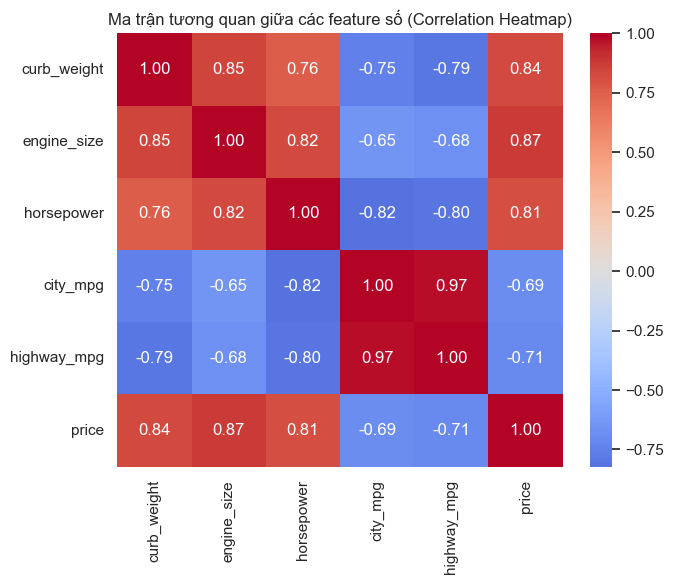

In [24]:
# TODO M2.5: correlation heatmap
fig, ax = plt.subplots(figsize=(7, 6))
corr_matrix = analysis_df[AUTO_FEATURES].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Ma trận tương quan giữa các feature số (Correlation Heatmap)")
plt.tight_layout()
plt.show()

**Nhận xét:** `engine_size`, `curb_weight`, `horsepower` đều tương quan dương mạnh với `price` (0.81–0.87) và tương quan âm mạnh với `city_mpg`/`highway_mpg` (-0.65 đến -0.82) — phản ánh đúng trực giác cơ khí: xe to, máy lớn, công suất cao thì vừa đắt vừa tốn xăng hơn. Đáng chú ý nhất là `city_mpg` và `highway_mpg` tương quan gần như tuyệt đối với nhau (r ≈ 0.97), nên hai biến này mang gần như cùng một lượng thông tin và có thể gây đa cộng tuyến nếu đưa cả hai vào một mô hình tuyến tính.

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

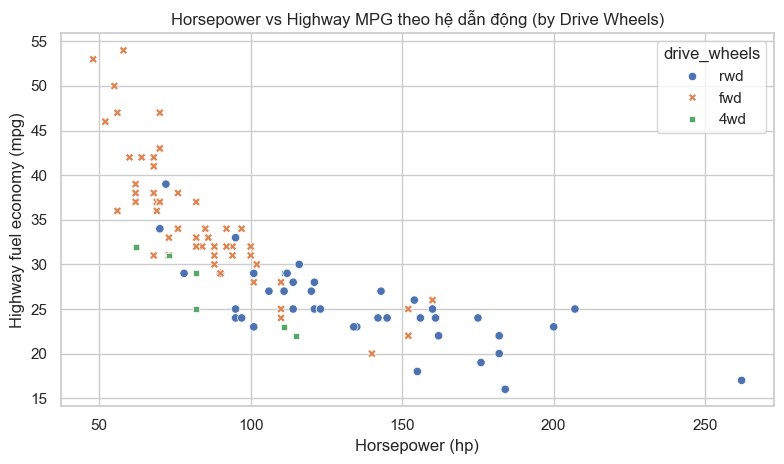

In [25]:
# TODO M2.6: biểu đồ tự chọn
# Câu hỏi: Hệ dẫn động (drive_wheels) ảnh hưởng thế nào đến đánh đổi giữa horsepower và highway_mpg?
fig, ax = plt.subplots()
sns.scatterplot(
    data=analysis_df, x="horsepower", y="highway_mpg",
    hue="drive_wheels", style="drive_wheels", ax=ax,
)
ax.set_title("Horsepower vs Highway MPG theo hệ dẫn động (by Drive Wheels)")
ax.set_xlabel("Horsepower (hp)")
ax.set_ylabel("Highway fuel economy (mpg)")
plt.tight_layout()
plt.show()

**Nhận xét:** Xe `rwd` (dẫn động cầu sau) tập trung ở vùng horsepower cao và highway_mpg thấp (trung bình ~132 hp, ~26 mpg, giá trung bình ~19,800 USD), trong khi xe `fwd` (dẫn động cầu trước) chiếm phần lớn ở vùng ngược lại (~86 hp, ~34 mpg, giá chỉ ~9,200 USD) — cho thấy `drive_wheels` không chỉ phân tách theo công suất/tiết kiệm nhiên liệu mà còn gắn liền với phân khúc giá, củng cố thêm cho mối tương quan âm horsepower–highway_mpg (r ≈ -0.81) đã thấy ở M2.5.

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

**Phát hiện chính:** (1) `price` lệch phải mạnh (skew ≈ 1.79), đa số xe nằm trong khoảng 5,000–15,000 USD, một nhóm nhỏ xe hạng sang (Mercedes-Benz, BMW, Jaguar, Porsche) kéo giá lên 30,000–45,400 USD, tạo 14/199 outlier theo z-score. (2) `engine_size` tương quan mạnh nhất với `price` (r ≈ 0.87), sau đó là `curb_weight` (0.84) và `horsepower` (0.81). (3) `city_mpg` và `highway_mpg` gần như là một biến lặp (r ≈ 0.97) nên chỉ cần giữ một trong hai khi xây mô hình. (4) `drive_wheels` phân tách rõ cả công suất lẫn giá: rwd mạnh hơn, tốn xăng hơn và đắt gần gấp đôi fwd.

**Hạn chế:** dataset chỉ có 205 mẫu xe đời 1985, đã cũ so với thị trường hiện nay; một số nhóm phụ như convertible, hardtop, xe 4wd chỉ có 6–8 mẫu, quá nhỏ để kết luận thống kê đáng tin cậy.

**Correlation ≠ causation:** `engine_size` tương quan dương mạnh với `price`, nhưng không phải engine lớn trực tiếp làm tăng giá — cả hai cùng bị chi phối bởi biến ẩn là phân khúc/thương hiệu, vì xe hạng sang vừa có engine lớn vừa được định giá cao do thương hiệu, không chỉ vì dung tích động cơ.

**Câu hỏi nên phân tích tiếp:** trong nhóm curb_weight, engine_size, horsepower vốn tương quan chặt nhau, yếu tố nào đóng góp độc lập nhiều nhất vào price khi đã kiểm soát các yếu tố còn lại, ví dụ qua hồi quy đa biến?